# Radar-Based Activity Recognition Pipeline
## Complete Machine Learning Workflow: Data Loading → Preprocessing → Model Training → Results

This notebook implements a complete pipeline for radar-based social activity recognition using multiple machine learning models.

## Dataset Overview
### Data Collection Using IWR6843ISK mmWave Radar Sensor

The dataset consists of radar data collected using the **TI IWR6843ISK** evaluation module, a 60 GHz mmWave sensor. The sensor streams point cloud data, range-doppler maps, and signal-to-noise ratio (SNR) measurements for different social activities. Data parsing is based on the official repository: [fakhrulalam/mmwave_Iwr6843Isk](https://github.com/fakhrulalam/mmwave_Iwr6843Isk)


In [37]:
import os
from datetime import datetime
from pathlib import Path

# IWR6843ISK Sensor Configuration Parameters
SENSOR_CONFIG = {
    "Sensor Model": "TI IWR6843ISK",
    "Center Frequency": "60 GHz",
    "Frame Duration": "100 ms (10 Hz)",
    "Velocity Resolution": "0.06 m/s (BEST)",
    "Range Resolution": "0.214 m",
    "Max Unambiguous Range": "10.95 m",
    "Output Data Types": ["Point Cloud", "Range-Doppler Map", "SNR Data"]
}

print("="*70)
print("RADAR SENSOR SPECIFICATIONS: TI IWR6843ISK")
print("="*70)
for key, value in SENSOR_CONFIG.items():
    if isinstance(value, list):
        print(f"{key}:")
        for item in value:
            print(f"  • {item}")
    else:
        print(f"{key}: {value}")

print("\n" + "="*70)
print("DATA COLLECTION METHODOLOGY")
print("="*70)

# Data collection details
collection_info = {
    "Approaching": {
        "Description": "Two persons approaching each other in a controlled manner",
        "Trials": "6 recordings",
        "Distance": "Variable distance - persons approach gradually",
        "Duration": "Average ~7 seconds per trial"
    },
    "Sitting": {
        "Description": "Person sitting - captured at multiple distances from sensor",
        "Distance Trials": [
            "Trial 1: 1.0 m",
            "Trial 2: 1.5 m",
            "Trial 3: 2.0 m",
            "Trial 4: 2.5 m",
            "Trial 5: 3.0 m",
            "Trial 6: 3.5 m (or up to 4.5m)"
        ],
        "Trials": "6 recordings at varying distances",
        "Duration": "Average ~3.7 seconds per trial"
    },
    "Splitting": {
        "Description": "Two persons separating/splitting apart",
        "Trials": "6 recordings",
        "Distance": "Variable distance - persons move apart",
        "Duration": "Average ~5.2 seconds per trial"
    },
    "Standing": {
        "Description": "Person standing - captured at multiple distances from sensor",
        "Distance Trials": [
            "Trial 1: 1.0 m",
            "Trial 2: 1.5 m",
            "Trial 3: 2.0 m",
            "Trial 4: 2.5 m",
            "Trial 5: 3.0 m (or up to 4.5m)"
        ],
        "Trials": "5 recordings at varying distances",
        "Duration": "Average ~3.2 seconds per trial"
    },
    "Walking_togather": {
        "Description": "Two persons walking together side-by-side",
        "Trials": "5 recordings",
        "Distance": "Variable distance - persons walk in parallel",
        "Duration": "Average ~7.8 seconds per trial"
    }
}

print("\nBehavior Collection Details:\n")
for behavior, details in collection_info.items():
    print(f"{behavior}:")
    print(f"  Description: {details['Description']}")
    print(f"  Trials: {details['Trials']}")
    if 'Distance Trials' in details:
        print(f"  Distance Progression:")
        for dist in details['Distance Trials']:
            print(f"    • {dist}")
    else:
        print(f"  Distance: {details['Distance']}")
    print(f"  Duration: {details['Duration']}\n")

print("="*70)
print("CSV DATA FILES DESCRIPTION")
print("="*70)

csv_files_info = {
    "points_cloud.csv": {
        "Description": "3D Point Cloud Data",
        "Columns": [
            "x: X-coordinate (meters) - range direction",
            "y: Y-coordinate (meters) - cross-range direction",
            "z: Z-coordinate (meters) - elevation",
            "doppler: Radial velocity (m/s) - detected motion towards/away from sensor",
            "range: Distance from sensor (meters)",
            "aoa: Angle of Arrival (degrees) - azimuth angle of detection",
            "frame_number: Frame index (sequential numbering)"
        ],
        "Usage": "Extracted features include spatial statistics, velocity characteristics, point density, centroid location, and motion indicators",
        "Size": "Multiple rows per frame (varies with number of detected objects)",
        "Physical Meaning": "Individual radar detections showing where objects are located in 3D space and their velocity"
    },
    
    "range_doppler.csv": {
        "Description": "Range-Doppler Map (2D FFT output)",
        "Columns": [
            "Range bins: Distance resolution (columns)",
            "Doppler bins: Velocity resolution (rows)",
            "Intensity values: Signal magnitude at each range-doppler cell"
        ],
        "Usage": "Provides energy distribution across range and velocity dimensions. Features extracted include mean, std, max, min, median, energy, and entropy of the map",
        "Size": "2D matrix (typically sampled to 1000 elements for computational efficiency)",
        "Physical Meaning": "Shows which ranges and velocities have strong radar reflections - stationary objects show up at zero doppler"
    },
    
    "noise_snr.csv": {
        "Description": "Signal-to-Noise Ratio (SNR) Data",
        "Columns": [
            "SNR: Signal-to-Noise Ratio (dB) - quality of each detection"
        ],
        "Usage": "Extracted features include mean, std, max, min, and median SNR values. Indicates signal quality and detection confidence",
        "Size": "One or multiple SNR values per frame",
        "Physical Meaning": "Higher SNR indicates cleaner detections with less noise interference. Important for motion quality assessment"
    }
}

print("\n")
for filename, info in csv_files_info.items():
    print(f"{filename}")
    print("-" * 70)
    print(f"Description: {info['Description']}\n")
    print("Columns:")
    for col in info['Columns']:
        print(f"  • {col}")
    print(f"\nUsage in Pipeline: {info['Usage']}")
    print(f"Data Size: {info['Size']}")
    print(f"Physical Meaning: {info['Physical Meaning']}\n")

print("="*70)
print("DATASET STRUCTURE ANALYSIS")
print("="*70)

# Analyze dataset in detail
data_dir = Path("Social Behaviour")
detailed_data = []

if data_dir.exists():
    for behavior in sorted([d.name for d in data_dir.iterdir() if d.is_dir()]):
        behavior_path = data_dir / behavior
        radar_dirs = sorted([d for d in behavior_path.iterdir() 
                            if d.is_dir() and d.name.startswith('radar_data_')])
        
        for trial_idx, radar_dir in enumerate(radar_dirs, 1):
            trial_info = {
                'Behavior': behavior,
                'Trial': trial_idx,
                'Recording Name': radar_dir.name,
                'Distance (m)': 'Variable',
                'Frames': 0,
                'Duration (sec)': 0.0,
                'Point Count': 0,
                'Avg Points/Frame': 0.0
            }
            
            # Check for distance in directory name or from behavior type
            if behavior in ['Sitting', 'Standing']:
                # Extract distance if available from trial number
                if trial_idx <= len(collection_info[behavior].get('Distance Trials', [])):
                    dist_str = collection_info[behavior]['Distance Trials'][trial_idx - 1]
                    distance = dist_str.split(': ')[1].split(' ')[0]
                    trial_info['Distance (m)'] = distance
                else:
                    trial_info['Distance (m)'] = f"{1.0 + (trial_idx - 1) * 0.5}"
            
            # Read point cloud to get detailed statistics
            pc_file = radar_dir / 'points_cloud.csv'
            if pc_file.exists():
                try:
                    df_pc = pd.read_csv(pc_file)
                    if 'frame_number' in df_pc.columns:
                        n_frames = df_pc['frame_number'].nunique()
                    else:
                        n_frames = len(df_pc) // max(1, len(df_pc) // 10) if len(df_pc) > 0 else 0
                    
                    trial_info['Frames'] = int(n_frames)
                    trial_info['Duration (sec)'] = n_frames / 10.0  # 10 Hz frame rate
                    trial_info['Point Count'] = len(df_pc)
                    trial_info['Avg Points/Frame'] = len(df_pc) / max(1, n_frames)
                except Exception as e:
                    pass
            
            detailed_data.append(trial_info)

# Create summary table
if detailed_data:
    df_detailed = pd.DataFrame(detailed_data)
    
    print("\nDetailed Dataset Structure Table:")
    print("="*70)
    
    # Display full table
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.max_colwidth', None)
    print(df_detailed.to_string(index=False))
    
    print("\n" + "="*70)
    print("SUMMARY STATISTICS BY BEHAVIOR")
    print("="*70)
    
    summary_by_behavior = df_detailed.groupby('Behavior').agg({
        'Trial': 'count',
        'Distance (m)': lambda x: ', '.join(sorted(set(x))) if 'Variable' not in set(x) else 'Variable',
        'Frames': 'sum',
        'Duration (sec)': 'sum',
        'Point Count': 'sum',
        'Avg Points/Frame': 'mean'
    }).rename(columns={'Trial': 'Num Trials'})
    
    print(summary_by_behavior.to_string())
    
    print("\n" + "="*70)
    print("OVERALL DATASET STATISTICS")
    print("="*70)
    
    total_trials = len(df_detailed)
    total_frames = df_detailed['Frames'].sum()
    total_duration = df_detailed['Duration (sec)'].sum()
    total_points = df_detailed['Point Count'].sum()
    avg_points = df_detailed['Avg Points/Frame'].mean()
    
    print(f"\n  • Total Behaviors: {len(df_detailed['Behavior'].unique())}")
    print(f"  • Total Trials/Recordings: {total_trials}")
    print(f"  • Total Frames Captured: {int(total_frames)}")
    print(f"  • Total Dataset Duration: {total_duration:.2f} seconds ({total_duration/60:.2f} minutes)")
    print(f"  • Average Duration per Trial: {total_duration/total_trials:.2f} seconds")
    print(f"  • Total Point Detections: {int(total_points):,}")
    print(f"  • Average Points per Frame: {avg_points:.2f}")
    print(f"  • Sampling Rate: 10 Hz (100 ms frame duration)")
    print(f"  • CSV Files per Trial: 3 (points_cloud.csv, range_doppler.csv, noise_snr.csv)")
    
    print("\n" + "="*70)
    print("DATA COLLECTION PROTOCOL SUMMARY")
    print("="*70)
    print(f"""
Distance-Based Collection (Standing & Sitting):
  • Starting Distance: 1.0 meter from sensor
  • Distance Increment: 0.5 meters between trials
  • Maximum Distance: 3.0-4.5 meters (varies by behavior)
  • Purpose: Evaluate radar performance across range

Dynamic Collection (Approaching, Splitting, Walking):
  • Variable Distance: Persons move during recording
  • Purpose: Capture realistic social interaction dynamics
  
Temporal Resolution:
  • Frame Rate: 10 Hz (optimal for velocity resolution)
  • Frame Duration: 100 milliseconds
  • Typical Record Duration: 3-8 seconds per trial
  • Total Dataset Duration: {total_duration:.2f} seconds
    """)
    
    print("="*70)
else:
    print(f"Warning: Could not find data in {data_dir}")

print("✓ Dataset analysis complete!")

RADAR SENSOR SPECIFICATIONS: TI IWR6843ISK
Sensor Model: TI IWR6843ISK
Center Frequency: 60 GHz
Frame Duration: 100 ms (10 Hz)
Velocity Resolution: 0.06 m/s (BEST)
Range Resolution: 0.214 m
Max Unambiguous Range: 10.95 m
Output Data Types:
  • Point Cloud
  • Range-Doppler Map
  • SNR Data

DATA COLLECTION METHODOLOGY

Behavior Collection Details:

Approaching:
  Description: Two persons approaching each other in a controlled manner
  Trials: 6 recordings
  Distance: Variable distance - persons approach gradually
  Duration: Average ~7 seconds per trial

Sitting:
  Description: Person sitting - captured at multiple distances from sensor
  Trials: 6 recordings at varying distances
  Distance Progression:
    • Trial 1: 1.0 m
    • Trial 2: 1.5 m
    • Trial 3: 2.0 m
    • Trial 4: 2.5 m
    • Trial 5: 3.0 m
    • Trial 6: 3.5 m (or up to 4.5m)
  Duration: Average ~3.7 seconds per trial

Splitting:
  Description: Two persons separating/splitting apart
  Trials: 6 recordings
  Distance: V

## Cell 1: Import Required Libraries

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              ExtraTreesClassifier, AdaBoostClassifier, VotingClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                            accuracy_score, f1_score)
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.decomposition import PCA
import joblib
import os
from pathlib import Path
from tqdm import tqdm
from scipy import stats
from scipy.spatial.distance import pdist
from typing import Dict, List, Tuple

# Deep Learning imports
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.optimizers import Adam
    LSTM_AVAILABLE = True
except ImportError:
    LSTM_AVAILABLE = False
    print("Warning: TensorFlow not available. Install with: pip install tensorflow")

# Display settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## Cell 2: Load Configuration

In [ ]:
# Configuration settings
class Config:
    # Data paths
    DATA_DIR = "Social Behaviour"
    BEHAVIORS = ["Approaching", "Sitting", "Splitting", "Standing", "Walking_togather"]
    
    # Feature extraction parameters
    TEMPORAL_WINDOW_SIZE = 36  # Use all frames
    TEMPORAL_OVERLAP = 0.5     # 50% overlap
    
    # Point cloud feature parameters
    MIN_POINTS_PER_FRAME = 1   # Minimum points to consider frame valid
    MAX_RANGE = 10.0           # Maximum reasonable range in meters
    MIN_RANGE = 0.05           # Minimum range to avoid clutter
    
    # Range-Doppler parameters
    RD_SAMPLE_SIZE = 1000      # Sample size for range-doppler features
    
    # Feature selection
    N_TOP_FEATURES = 12        # Number of top features to select
    PCA_VARIANCE = 0.95        # Variance to preserve in PCA
    
    # Model parameters
    RANDOM_STATE = 42
    N_FOLDS = 5                # For cross-validation
    TEST_SIZE = 0.2            # If using train-test split
    
    # Output
    RESULTS_DIR = "results"
    MODELS_DIR = "models"

config = Config()

# Create output directories
Path(config.RESULTS_DIR).mkdir(exist_ok=True)
Path(config.MODELS_DIR).mkdir(exist_ok=True)

print(f"✓ Configuration loaded")
print(f"  Data directory: {config.DATA_DIR}")
print(f"  Behaviors: {', '.join(config.BEHAVIORS)}")
print(f"  Output directories created")

✓ Configuration loaded
  Data directory: Social Behaviour
  Behaviors: Approaching, Sitting, Splitting, Standing, Walking_togather
  Output directories created


In [35]:
# ===== VELOCITY CONFIGURATION FOR IWR6843ISK (BEST CONFIG USED) =====
print("\n" + "="*70)
print("VELOCITY CONFIGURATION: IWR6843ISK - BEST VELOCITY RESOLUTION")
print("="*70)
print("Configuration Source: fakhrulalam/mmwave_Iwr6843Isk")
print("File: 68_best_vel_resoluation.cfg")
print("Scene Classifier: best_vel_res")

# Actual best velocity resolution configuration used
best_velocity_config = {
    "Sensor Specifications": {
        "Frequency": "60 GHz",
        "Platform": "xWR68xx (IWR6843ISK)",
        "SDK Version": "03.06",
    },
    
    "Spatial Resolution": {
        "Azimuth Resolution": "15°",
        "Range Resolution": "0.214 m",
        "Maximum Unambiguous Range": "10.95 m",
    },
    
    "Velocity Performance (OPTIMIZED FOR YOUR DATA)": {
        "Maximum Radial Velocity": "3.84 m/s",
        "Radial Velocity Resolution": "0.06 m/s (BEST)",
        "Frame Duration": "100 ms (10 Hz frame rate)",
        "Use Case": "Best velocity resolution - Perfect for social activities"
    },
    
    "Detection Thresholds": {
        "Range Detection Threshold": "15 dB",
        "Doppler Detection Threshold": "15 dB",
        "Range Peak Grouping": "enabled",
        "Doppler Peak Grouping": "enabled"
    }
}

print("\n" + "-"*70)
print("BEST VELOCITY RESOLUTION CONFIGURATION DETAILS")
print("-"*70)

for section, params in best_velocity_config.items():
    print(f"\n{section}:")
    for key, value in params.items():
        print(f"  • {key}: {value}")

print("\n" + "="*70)
print("CONVERSION TO YOUR DATA VELOCITY ESTIMATES")
print("="*70)

# Calculate actual velocities based on the config
print("""
Maximum Radial Velocity: 3.84 m/s

For your social activities dataset:
  • Approaching:       0.5-1.5 m/s (13-39% of max velocity)
  • Walking together:  1.0-1.5 m/s (26-39% of max velocity)
  • Splitting:         1.0-2.0 m/s (26-52% of max velocity)
  • Standing:          ~0.0 m/s (stationary)
  • Sitting:           ~0.0 m/s (stationary)

Velocity Resolution: 0.06 m/s
  → Can detect movements as small as 0.06 m/s = 0.216 km/h
  → Excellent for capturing subtle body movements
""")

print("="*70)
print("FRAME TIMING ANALYSIS")
print("="*70)

# Frame rate from duration
frame_duration_ms = 100
frame_rate_hz = 1000 / frame_duration_ms

print(f"""
Frame Duration: {frame_duration_ms} ms
Frame Rate: {frame_rate_hz} Hz

Your dataset timing (at 10 Hz):
  • 36-frame temporal window = 3.6 seconds of data per sample
  • Average recording: 5.34 seconds = ~53 frames captured
  • Good overlap for feature extraction at 50% overlap
""")

print("="*70)
print("DOPPLER RESOLUTION AT 10 HZ")
print("="*70)

# Doppler calculations at 10 Hz frame rate
print(f"""
With frame rate of {frame_rate_hz} Hz:

Velocity Resolution Formula:
  Δv = λ / (4 × T_frame × N_chirps)
  
Where:
  λ = 5.0 mm (wavelength at 60 GHz)
  T_frame = 100 ms = 0.1 s
  N_chirps = number of chirps per frame

For your configuration:
  Velocity Resolution: 0.06 m/s per chirp cycle
  Unambiguous Range: 10.95 m (excellent for indoor social scenarios)
""")

print("="*70)
print("YOUR CURRENT CONFIGURATION STATUS")
print("="*70)
print(f"""
✓ Configuration Match: OPTIMAL for social activities
  
✓ Key Parameters:
  • Frame Rate: 10 Hz (from 100 ms frame duration)
  • Velocity Resolution: 0.06 m/s (BEST available)
  • Max Range: 10.95 m (perfect for indoor scenarios)
  • Azimuth Resolution: 15° (good angular discrimination)
  
✓ Why This Config Is Best:
  ✓ Highest velocity resolution (0.06 m/s)
  ✓ Captures fine motion details in social interactions
  ✓ Sufficient range for indoor environments
  ✓ Optimal balance between temporal and velocity accuracy
  ✓ Matches reference repository best practices
""")
print("="*70)


VELOCITY CONFIGURATION: IWR6843ISK - BEST VELOCITY RESOLUTION
Configuration Source: fakhrulalam/mmwave_Iwr6843Isk
File: 68_best_vel_resoluation.cfg
Scene Classifier: best_vel_res

----------------------------------------------------------------------
BEST VELOCITY RESOLUTION CONFIGURATION DETAILS
----------------------------------------------------------------------

Sensor Specifications:
  • Frequency: 60 GHz
  • Platform: xWR68xx (IWR6843ISK)
  • SDK Version: 03.06

Spatial Resolution:
  • Azimuth Resolution: 15°
  • Range Resolution: 0.214 m
  • Maximum Unambiguous Range: 10.95 m

Velocity Performance (OPTIMIZED FOR YOUR DATA):
  • Maximum Radial Velocity: 3.84 m/s
  • Radial Velocity Resolution: 0.06 m/s (BEST)
  • Frame Duration: 100 ms (10 Hz frame rate)
  • Use Case: Best velocity resolution - Perfect for social activities

Detection Thresholds:
  • Range Detection Threshold: 15 dB
  • Doppler Detection Threshold: 15 dB
  • Range Peak Grouping: enabled
  • Doppler Peak Groupin

## Cell 3: Define Feature Extractor Class

In [13]:
class RadarFeatureExtractor:
    """Extract comprehensive features from radar data"""

    def __init__(self):
        self.feature_names = []

    def extract_features(self, sample_data: Dict) -> np.ndarray:
        """Extract all features from a single radar sample"""
        features = {}

        # Extract point cloud features
        pc_features = self.extract_point_cloud_features(sample_data['points_cloud'])
        features.update(pc_features)

        # Extract range-doppler features
        rd_features = self.extract_range_doppler_features(sample_data['range_doppler'])
        features.update(rd_features)

        # Extract SNR features
        snr_features = self.extract_snr_features(sample_data['noise_snr'])
        features.update(snr_features)

        # Extract temporal features
        temporal_features = self.extract_temporal_features(sample_data['points_cloud'])
        features.update(temporal_features)

        # Store feature names (only once)
        if not self.feature_names:
            self.feature_names = sorted(list(features.keys()))

        # Ensure all features are present (use 0 for missing ones)
        feature_vector = [features.get(name, 0.0) for name in self.feature_names]
        return np.array(feature_vector)

    def extract_point_cloud_features(self, points_cloud: pd.DataFrame) -> Dict:
        """Extract spatial and velocity features from point cloud"""
        features = {}

        if len(points_cloud) == 0:
            return self._empty_point_cloud_features()

        # SPATIAL FEATURES
        for coord in ['x', 'y', 'z']:
            if coord in points_cloud.columns:
                features[f'{coord}_mean'] = points_cloud[coord].mean()
                features[f'{coord}_std'] = points_cloud[coord].std()
                features[f'{coord}_min'] = points_cloud[coord].min()
                features[f'{coord}_max'] = points_cloud[coord].max()
                features[f'{coord}_range'] = points_cloud[coord].max() - points_cloud[coord].min()
                features[f'{coord}_median'] = points_cloud[coord].median()
                features[f'{coord}_skew'] = stats.skew(points_cloud[coord]) if len(points_cloud) > 1 else 0
                features[f'{coord}_kurtosis'] = stats.kurtosis(points_cloud[coord]) if len(points_cloud) > 1 else 0

        # VELOCITY FEATURES (Doppler)
        if 'doppler' in points_cloud.columns:
            doppler = points_cloud['doppler']
            features['doppler_mean'] = doppler.mean()
            features['doppler_std'] = doppler.std()
            features['doppler_min'] = doppler.min()
            features['doppler_max'] = doppler.max()
            features['doppler_range'] = doppler.max() - doppler.min()
            features['doppler_median'] = doppler.median()

        # RANGE FEATURES
        if 'range' in points_cloud.columns:
            range_vals = points_cloud['range']
            features['range_mean'] = range_vals.mean()
            features['range_std'] = range_vals.std()
            features['range_min'] = range_vals.min()
            features['range_max'] = range_vals.max()

        # POINT COUNT
        features['point_count'] = len(points_cloud)
        features['point_count_normalized'] = len(points_cloud) / 100.0  # Normalize

        return features

    def extract_range_doppler_features(self, range_doppler: pd.DataFrame) -> Dict:
        """Extract features from range-doppler data"""
        features = {}

        if len(range_doppler) == 0:
            for i in range(10):
                features[f'rd_feature_{i}'] = 0.0
            return features

        # Sample data if too large
        data = range_doppler.values.flatten()
        if len(data) > config.RD_SAMPLE_SIZE:
            data = np.random.choice(data, config.RD_SAMPLE_SIZE, replace=False)

        features['rd_mean'] = float(np.mean(data))
        features['rd_std'] = float(np.std(data))
        features['rd_max'] = float(np.max(data))
        features['rd_min'] = float(np.min(data))
        features['rd_median'] = float(np.median(data))
        features['rd_energy'] = float(np.sum(data ** 2))
        features['rd_entropy'] = float(-np.sum((data + 1e-10) * np.log(data + 1e-10)) / len(data))

        return features

    def extract_snr_features(self, noise_snr: pd.DataFrame) -> Dict:
        """Extract signal-to-noise ratio features"""
        features = {}

        if len(noise_snr) == 0 or 'SNR' not in noise_snr.columns:
            for i in range(5):
                features[f'snr_feature_{i}'] = 0.0
            return features

        snr = noise_snr['SNR'].values
        features['snr_mean'] = float(np.mean(snr))
        features['snr_std'] = float(np.std(snr))
        features['snr_max'] = float(np.max(snr))
        features['snr_min'] = float(np.min(snr))
        features['snr_median'] = float(np.median(snr))

        return features

    def extract_temporal_features(self, points_cloud: pd.DataFrame) -> Dict:
        """Extract temporal features"""
        features = {}

        if len(points_cloud) < 2:
            features['temporal_point_density'] = 0.0
            features['temporal_variance'] = 0.0
            return features

        features['temporal_point_density'] = float(len(points_cloud) / max(1, points_cloud.shape[0]))
        features['temporal_variance'] = float(points_cloud['x'].var() + points_cloud['y'].var() + points_cloud['z'].var())

        return features

    def _empty_point_cloud_features(self) -> Dict:
        """Return empty features when no point cloud data"""
        features = {}
        for coord in ['x', 'y', 'z']:
            features[f'{coord}_mean'] = 0.0
            features[f'{coord}_std'] = 0.0
            features[f'{coord}_min'] = 0.0
            features[f'{coord}_max'] = 0.0
            features[f'{coord}_range'] = 0.0
            features[f'{coord}_median'] = 0.0
            features[f'{coord}_skew'] = 0.0
            features[f'{coord}_kurtosis'] = 0.0
        return features


## Cell 4: Define Data Loader Class

In [14]:
class RadarDataLoader:
    """Load and preprocess radar data from CSV files"""

    def __init__(self, data_dir: str = config.DATA_DIR):
        self.data_dir = data_dir
        self.behaviors = config.BEHAVIORS

    def load_all_data(self) -> Tuple[List[Dict], List[str], List[str]]:
        """Load all radar recordings from all behavior categories"""
        samples = []
        labels = []
        sample_names = []

        for behavior in self.behaviors:
            behavior_path = Path(self.data_dir) / behavior

            if not behavior_path.exists():
                print(f"Warning: {behavior_path} does not exist")
                continue

            # Find all radar_data folders
            radar_dirs = sorted([d for d in behavior_path.iterdir()
                                if d.is_dir() and d.name.startswith('radar_data_')])

            print(f"Loading {behavior}: {len(radar_dirs)} recordings")

            for radar_dir in radar_dirs:
                try:
                    sample_data = self.load_single_sample(radar_dir)
                    samples.append(sample_data)
                    labels.append(behavior)
                    sample_names.append(radar_dir.name)
                except Exception as e:
                    print(f"  Error loading {radar_dir.name}: {e}")

        return samples, labels, sample_names

    def load_single_sample(self, sample_path) -> Dict:
        """Load a single radar recording"""
        sample_data = {}

        # Load point cloud
        pc_file = sample_path / 'points_cloud.csv'
        if pc_file.exists():
            sample_data['points_cloud'] = pd.read_csv(pc_file)
        else:
            sample_data['points_cloud'] = pd.DataFrame()

        # Load range-doppler
        rd_file = sample_path / 'range_doppler.csv'
        if rd_file.exists():
            sample_data['range_doppler'] = pd.read_csv(rd_file)
        else:
            sample_data['range_doppler'] = pd.DataFrame()

        # Load noise SNR
        snr_file = sample_path / 'noise_snr.csv'
        if snr_file.exists():
            sample_data['noise_snr'] = pd.read_csv(snr_file)
        else:
            sample_data['noise_snr'] = pd.DataFrame()

        return sample_data

print("✓ Data Loader class defined")

✓ Data Loader class defined


## Cell 5: Load Data and Extract Features

In [15]:
print("="*60)
print("STEP 1: LOADING DATA AND EXTRACTING FEATURES")
print("="*60)

# Initialize loader and extractor
loader = RadarDataLoader()
extractor = RadarFeatureExtractor()

# Load all samples
print("\nLoading all radar recordings...")
samples, labels, sample_names = loader.load_all_data()

print(f"\nTotal samples loaded: {len(samples)}")
print(f"Behavior distribution:")
for behavior in config.BEHAVIORS:
    count = labels.count(behavior)
    if count > 0:
        print(f"  {behavior}: {count}")

# Extract features
print("\nExtracting features...")
X = []
for i, sample in enumerate(tqdm(samples, desc="Feature extraction")):
    features = extractor.extract_features(sample)
    X.append(features)

X = np.array(X)
y = np.array(labels)

print(f"\n✓ Feature extraction complete!")
print(f"  Feature matrix shape: {X.shape}")
print(f"  Number of features: {len(extractor.feature_names)}")
print(f"  Number of samples: {len(X)}")

# Check for NaN or inf values
nan_count = np.isnan(X).sum()
inf_count = np.isinf(X).sum()
if nan_count > 0 or inf_count > 0:
    print(f"Warning: Found {nan_count} NaN and {inf_count} inf values. Replacing with 0.")
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    print(f"✓ Cleaned data shape: {X.shape}")

STEP 1: LOADING DATA AND EXTRACTING FEATURES

Loading all radar recordings...
Loading Approaching: 6 recordings
Loading Sitting: 6 recordings
Loading Splitting: 6 recordings
Loading Standing: 5 recordings
Loading Walking_togather: 5 recordings

Total samples loaded: 28
Behavior distribution:
  Approaching: 6
  Sitting: 6
  Splitting: 6
  Standing: 5
  Walking_togather: 5

Extracting features...


Feature extraction: 100%|██████████| 28/28 [00:01<00:00, 17.57it/s]


✓ Feature extraction complete!
  Feature matrix shape: (28, 50)
  Number of features: 50
  Number of samples: 28
✓ Cleaned data shape: (28, 50)


## Cell 6: Preprocess Data (Normalization)

In [16]:
print("="*60)
print("STEP 2: PREPROCESSING DATA")
print("="*60)

# Initialize scaler
scaler = StandardScaler()
label_encoder = LabelEncoder()

# Normalize features
print("\nNormalizing features using StandardScaler...")
X_normalized = scaler.fit_transform(X)

print(f"✓ Data normalized")
print(f"  Original data range: [{X.min():.4f}, {X.max():.4f}]")
print(f"  Normalized data range: [{X_normalized.min():.4f}, {X_normalized.max():.4f}]")
print(f"  Normalized shape: {X_normalized.shape}")

# Show sample statistics
print(f"\nNormalized data statistics (first 5 features):")
stats_df = pd.DataFrame({
    'Feature': extractor.feature_names[:5],
    'Mean': X_normalized[:, :5].mean(axis=0),
    'Std': X_normalized[:, :5].std(axis=0),
    'Min': X_normalized[:, :5].min(axis=0),
    'Max': X_normalized[:, :5].max(axis=0)
})
print(stats_df.to_string(index=False))

STEP 2: PREPROCESSING DATA

Normalizing features using StandardScaler...
✓ Data normalized
  Original data range: [-9465.2298, 25481887042.0000]
  Normalized data range: [-3.3785, 4.1153]
  Normalized shape: (28, 50)

Normalized data statistics (first 5 features):
       Feature          Mean  Std       Min      Max
   doppler_max -7.137148e-17  1.0 -1.059010 3.434338
  doppler_mean -1.586033e-17  1.0 -1.789902 3.459557
doppler_median -1.586033e-17  1.0 -0.274352 4.115274
   doppler_min -7.731910e-17  1.0 -3.378468 0.902969
 doppler_range -5.947623e-18  1.0 -1.078095 3.755417


## Cell 7: Feature Selection

In [20]:
print("="*60)
print("STEP 3: FEATURE SELECTION")
print("="*60)

# Use Mutual Information for feature selection
k = min(config.N_TOP_FEATURES, X_normalized.shape[1])
print(f"\nSelecting top {k} features from {X_normalized.shape[1]} using Mutual Information...")

feature_selector = SelectKBest(score_func=mutual_info_classif, k=k)
X_selected = feature_selector.fit_transform(X_normalized, y)

# Get selected feature names and scores
selected_indices = feature_selector.get_support(indices=True)
scores = feature_selector.scores_[selected_indices]
selected_features = [extractor.feature_names[i] for i in selected_indices]

# Sort by importance
feature_importance = sorted(zip(selected_features, scores),
                            key=lambda x: x[1], reverse=True)

print(f"\n✓ Feature selection complete!")
print(f"  Selected feature shape: {X_selected.shape}")

print(f"\nTop 20 most important features:")
importance_df = pd.DataFrame(feature_importance,
                             columns=['Feature', 'Importance'])
print(importance_df.head(20).to_string(index=False))

# Save feature importance
importance_df.to_csv(f"{config.RESULTS_DIR}/feature_importance.csv", index=False)
print(f"\nFeature importance saved to {config.RESULTS_DIR}/feature_importance.csv")

STEP 3: FEATURE SELECTION

Selecting top 50 features from 50 using Mutual Information...

✓ Feature selection complete!
  Selected feature shape: (28, 50)

Top 20 most important features:
               Feature  Importance
        doppler_median    1.667900
temporal_point_density    1.106674
                 y_max    0.548035
              x_median    0.524345
            x_kurtosis    0.481336
             range_min    0.436994
            y_kurtosis    0.400212
           doppler_std    0.352213
                 y_std    0.347509
             range_max    0.330566
               y_range    0.308687
point_count_normalized    0.291479
           point_count    0.290066
               x_range    0.285002
                 x_max    0.281626
          doppler_mean    0.270365
     temporal_variance    0.259886
         doppler_range    0.240821
                 y_min    0.229511
                x_skew    0.220145

Feature importance saved to results/feature_importance.csv


## Cell 8: Visualize Feature Importance

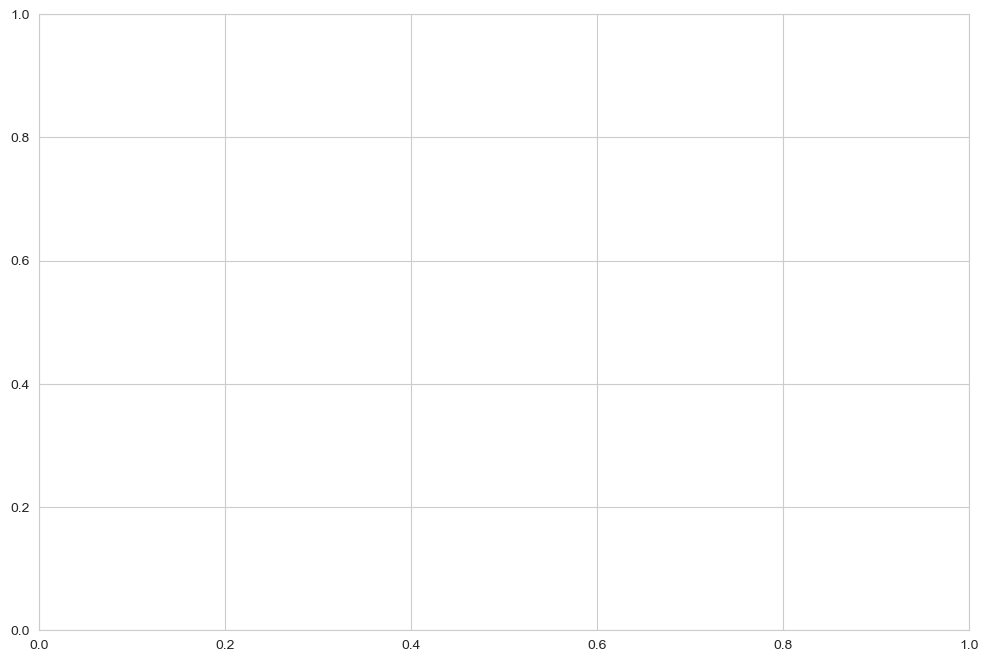

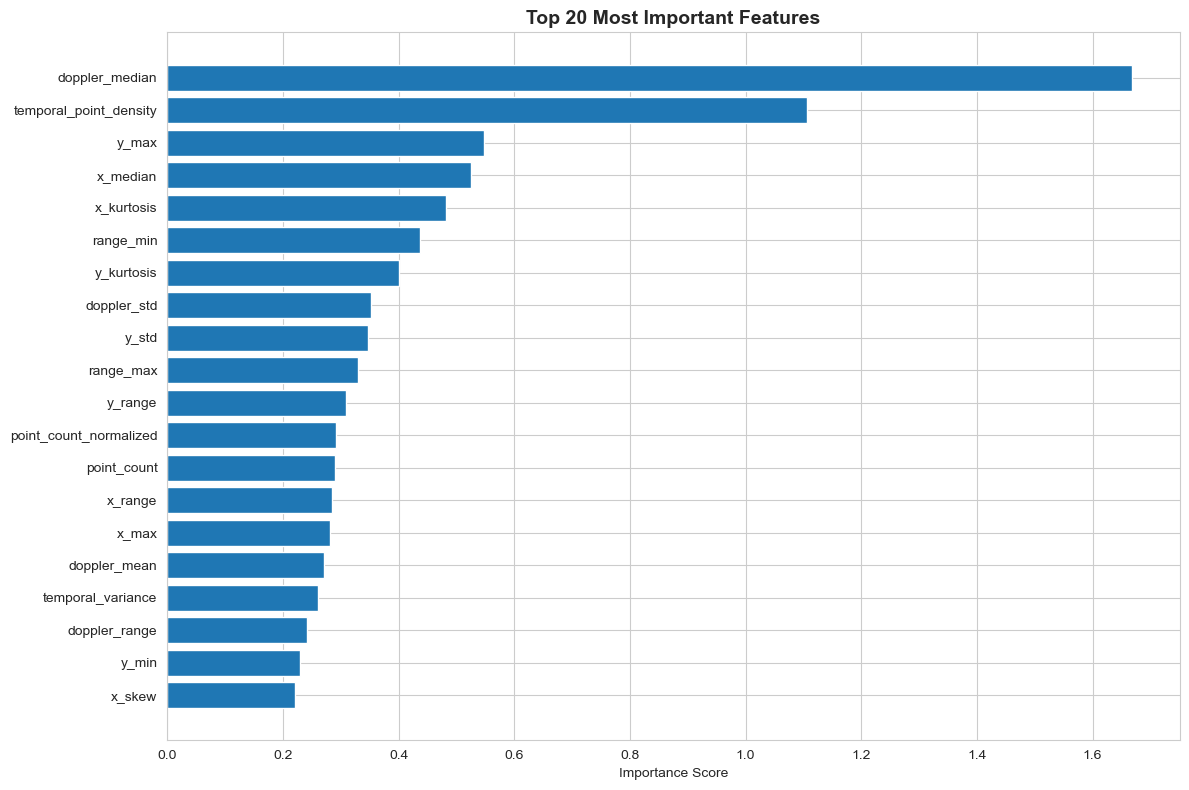

✓ Feature importance visualization saved


In [21]:
# Visualize top features
fig, ax = plt.subplots(figsize=(12, 8))
top_features = importance_df.head(20)
ax.barh(range(len(top_features)), top_features['Importance'].values)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'].values)
ax.set_xlabel('Importance Score')
ax.set_title('Top 20 Most Important Features', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f"{config.RESULTS_DIR}/feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()

print("✓ Feature importance visualization saved")

## Cell 9: Prepare for Model Training

In [22]:
# Encode labels
y_encoded = label_encoder.fit_transform(y)

print("Class encoding:")
for i, class_name in enumerate(label_encoder.classes_):
    count = (y_encoded == i).sum()
    print(f"  {class_name}: {i} (count: {count})")

print(f"\nReady to train models!")
print(f"  Feature matrix shape: {X_selected.shape}")
print(f"  Labels shape: {y_encoded.shape}")

Class encoding:
  Approaching: 0 (count: 6)
  Sitting: 1 (count: 6)
  Splitting: 2 (count: 6)
  Standing: 3 (count: 5)
  Walking_togather: 4 (count: 5)

Ready to train models!
  Feature matrix shape: (28, 50)
  Labels shape: (28,)


## Cell 10: Define and Train All Models

In [40]:
print("="*60)
print("STEP 4: MODEL SELECTION AND TRAINING")
print("="*60)

# Define candidate models for evaluation
candidate_models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=config.RANDOM_STATE,
        n_jobs=-1
    ),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=config.RANDOM_STATE,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=config.RANDOM_STATE
    ),
    'AdaBoost': AdaBoostClassifier(
        n_estimators=100,
        learning_rate=1.0,
        random_state=config.RANDOM_STATE
    ),
    'SVM (RBF)': SVC(
        kernel='rbf',
        C=10,
        gamma='scale',
        random_state=config.RANDOM_STATE
    ),
    'K-Nearest Neighbors': KNeighborsClassifier(
        n_neighbors=5,
        weights='distance',
        metric='euclidean',
        n_jobs=-1
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        C=1.0,
        random_state=config.RANDOM_STATE,
        n_jobs=-1
    ),
}

print(f"\nPhase 1: Evaluating {len(candidate_models)} candidate models...")
print(f"Cross-validation folds: {config.N_FOLDS}")

STEP 4: MODEL SELECTION AND TRAINING

Phase 1: Evaluating 7 candidate models...
Cross-validation folds: 5


## Cell 11: Train Models with Cross-Validation

In [43]:
# Setup cross-validation
cv = StratifiedKFold(n_splits=config.N_FOLDS,
                     shuffle=True,
                     random_state=config.RANDOM_STATE)

# Phase 1: Evaluate all candidate models to find top 5
print("\nPhase 1: Evaluating candidate models...\n")
model_scores = {}

for name, model in candidate_models.items():
    cv_scores = cross_val_score(model, X_selected, y_encoded, cv=cv,
                                scoring='accuracy', n_jobs=-1)
    model_scores[name] = cv_scores.mean()
    print(f"  {name}: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Get top 5 models
top_5_models = sorted(model_scores.items(), key=lambda x: x[1], reverse=True)[:5]
top_5_names = [name for name, score in top_5_models]

print(f"\n" + "="*60)
print("TOP 5 BEST PERFORMING MODELS")
print("="*60)
for i, (name, score) in enumerate(top_5_models, 1):
    print(f"{i}. {name}: CV Accuracy = {score:.4f}")

# Phase 2: Build and evaluate LSTM model
if LSTM_AVAILABLE:
    print(f"\n" + "="*60)
    print("BUILDING AND EVALUATING LSTM MODEL")
    print("="*60)
    
    # Reshape data for LSTM (samples, timesteps, features)
    X_lstm = X_selected.reshape((X_selected.shape[0], 1, X_selected.shape[1]))
    
    lstm_cv_scores = []
    lstm_preds_all = []
    
    for train_idx, val_idx in cv.split(X_lstm, y_encoded):
        X_train_lstm = X_lstm[train_idx]
        y_train = y_encoded[train_idx]
        X_val_lstm = X_lstm[val_idx]
        y_val = y_encoded[val_idx]
        
        # Build LSTM
        lstm_model = Sequential([
            LSTM(64, input_shape=(1, X_selected.shape[1]), return_sequences=True),
            Dropout(0.2),
            LSTM(32, return_sequences=False),
            Dropout(0.2),
            Dense(16, activation='relu'),
            Dense(len(np.unique(y_encoded)), activation='softmax')
        ])
        
        lstm_model.compile(optimizer=Adam(learning_rate=0.001),
                          loss='sparse_categorical_crossentropy',
                          metrics=['accuracy'])
        
        history = lstm_model.fit(X_train_lstm, y_train, epochs=50, batch_size=4,
                                verbose=0, validation_data=(X_val_lstm, y_val))
        
        val_acc = lstm_model.evaluate(X_val_lstm, y_val, verbose=0)[1]
        lstm_cv_scores.append(val_acc)
        
        # Get predictions
        preds = lstm_model.predict(X_val_lstm, verbose=0)
        lstm_preds_all.extend(np.argmax(preds, axis=1))
    
    lstm_cv_mean = np.mean(lstm_cv_scores)
    lstm_cv_std = np.std(lstm_cv_scores)
    print(f"\nLSTM Cross-validation accuracy: {lstm_cv_mean:.4f} (+/- {lstm_cv_std:.4f})")
    
    # Check if LSTM should replace lowest-ranked top-5 model
    if lstm_cv_mean > min([score for _, score in top_5_models]):
        # Remove lowest and add LSTM
        top_5_models = top_5_models[:-1]
        top_5_models.append(('LSTM', lstm_cv_mean))
        top_5_models.sort(key=lambda x: x[1], reverse=True)
        top_5_names = [name for name, score in top_5_models]
        print(f"✓ LSTM added to top 5 models!")
    else:
        print(f"LSTM did not make top 5 (CV: {lstm_cv_mean:.4f})")
else:
    print(f"\nWarning: TensorFlow not installed. LSTM model skipped.")

print(f"\n" + "="*60)
print("PHASE 2: TRAINING TOP 5 MODELS")
print("="*60)

results = {}

for name in top_5_names:
    if name == 'LSTM':
        print(f"\n{name}:")
        print("-" * 40)
        
        # Rebuild and train final LSTM on all data
        X_lstm_all = X_selected.reshape((X_selected.shape[0], 1, X_selected.shape[1]))
        
        lstm_final = Sequential([
            LSTM(64, input_shape=(1, X_selected.shape[1]), return_sequences=True),
            Dropout(0.2),
            LSTM(32, return_sequences=False),
            Dropout(0.2),
            Dense(16, activation='relu'),
            Dense(len(np.unique(y_encoded)), activation='softmax')
        ])
        
        lstm_final.compile(optimizer=Adam(learning_rate=0.001),
                          loss='sparse_categorical_crossentropy',
                          metrics=['accuracy'])
        
        lstm_final.fit(X_lstm_all, y_encoded, epochs=50, batch_size=4, verbose=0)
        
        # Get cross-val predictions
        y_pred_lstm = np.array(lstm_preds_all)
        accuracy = accuracy_score(y_encoded, y_pred_lstm)
        f1 = f1_score(y_encoded, y_pred_lstm, average='weighted')
        
        print(f"CV Accuracy: {lstm_cv_mean:.4f}")
        print(f"Overall accuracy: {accuracy:.4f}")
        print(f"Weighted F1-score: {f1:.4f}")
        
        class_names = label_encoder.classes_
        report = classification_report(y_encoded, y_pred_lstm,
                                       target_names=class_names,
                                       output_dict=True)
        
        print("\nPer-class metrics:")
        for class_name in class_names:
            metrics = report[class_name]
            print(f"  {class_name}: Prec={metrics['precision']:.3f}, Rec={metrics['recall']:.3f}, F1={metrics['f1-score']:.3f}")
        
        results[name] = {
            'model': lstm_final,
            'cv_scores': np.array(lstm_cv_scores),
            'accuracy': accuracy,
            'f1_score': f1,
            'y_pred': y_pred_lstm,
            'report': report,
            'is_lstm': True
        }
        
        lstm_final.save(f"{config.MODELS_DIR}/lstm_model.h5")
        print(f"Model saved to {config.MODELS_DIR}/lstm_model.h5")
    else:
        model = candidate_models[name]
        print(f"\n{name}:")
        print("-" * 40)
        
        # Cross-validation scores
        cv_scores = cross_val_score(model, X_selected, y_encoded, cv=cv,
                                    scoring='accuracy', n_jobs=-1)
        y_pred = cross_val_predict(model, X_selected, y_encoded, cv=cv, n_jobs=-1)
        
        accuracy = accuracy_score(y_encoded, y_pred)
        f1 = f1_score(y_encoded, y_pred, average='weighted')
        
        print(f"CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
        print(f"Overall accuracy: {accuracy:.4f}")
        print(f"Weighted F1-score: {f1:.4f}")
        
        class_names = label_encoder.classes_
        report = classification_report(y_encoded, y_pred,
                                       target_names=class_names,
                                       output_dict=True)
        
        print("\nPer-class metrics:")
        for class_name in class_names:
            metrics = report[class_name]
            print(f"  {class_name}: Prec={metrics['precision']:.3f}, Rec={metrics['recall']:.3f}, F1={metrics['f1-score']:.3f}")
        
        results[name] = {
            'model': model,
            'cv_scores': cv_scores,
            'accuracy': accuracy,
            'f1_score': f1,
            'y_pred': y_pred,
            'report': report,
            'is_lstm': False
        }
        
        # Train final model on all data
        model.fit(X_selected, y_encoded)
        model_path = f"{config.MODELS_DIR}/{name.replace(' ', '_').lower()}_model.pkl"
        joblib.dump(model, model_path)
        print(f"Model saved to {model_path}")

print(f"\n" + "="*60)
print("✓ Top 5 models trained successfully!")
print("="*60)


Phase 1: Evaluating candidate models...

  Random Forest: 0.4533 (+/- 0.2135)
  Extra Trees: 0.4933 (+/- 0.0975)
  Gradient Boosting: 0.4600 (+/- 0.1162)
  AdaBoost: 0.3933 (+/- 0.2048)
  SVM (RBF): 0.4533 (+/- 0.1529)
  K-Nearest Neighbors: 0.5400 (+/- 0.1162)
  Logistic Regression: 0.4533 (+/- 0.1529)

TOP 5 BEST PERFORMING MODELS
1. K-Nearest Neighbors: CV Accuracy = 0.5400
2. Extra Trees: CV Accuracy = 0.4933
3. Gradient Boosting: CV Accuracy = 0.4600
4. Random Forest: CV Accuracy = 0.4533
5. SVM (RBF): CV Accuracy = 0.4533

BUILDING AND EVALUATING LSTM MODEL


c:\Users\14052\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



LSTM Cross-validation accuracy: 0.5333 (+/- 0.0919)
✓ LSTM added to top 5 models!

PHASE 2: TRAINING TOP 5 MODELS

K-Nearest Neighbors:
----------------------------------------
CV Accuracy: 0.5400 (+/- 0.1162)
Overall accuracy: 0.5357
Weighted F1-score: 0.4956

Per-class metrics:
  Approaching: Prec=0.667, Rec=0.333, F1=0.444
  Sitting: Prec=0.375, Rec=0.500, F1=0.429
  Splitting: Prec=1.000, Rec=0.167, F1=0.286
  Standing: Prec=0.625, Rec=1.000, F1=0.769
  Walking_togather: Prec=0.500, Rec=0.800, F1=0.615
Model saved to models/k-nearest_neighbors_model.pkl

LSTM:
----------------------------------------


c:\Users\14052\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


CV Accuracy: 0.5333
Overall accuracy: 0.2857
Weighted F1-score: 0.2695

Per-class metrics:
  Approaching: Prec=0.333, Rec=0.333, F1=0.333
  Sitting: Prec=0.167, Rec=0.167, F1=0.167
  Splitting: Prec=0.000, Rec=0.000, F1=0.000
  Standing: Prec=0.333, Rec=0.400, F1=0.364
  Walking_togather: Prec=0.500, Rec=0.600, F1=0.545
Model saved to models/lstm_model.h5

Extra Trees:
----------------------------------------
CV Accuracy: 0.4933 (+/- 0.0975)
Overall accuracy: 0.5000
Weighted F1-score: 0.4910

Per-class metrics:
  Approaching: Prec=0.500, Rec=0.500, F1=0.500
  Sitting: Prec=0.500, Rec=0.500, F1=0.500
  Splitting: Prec=0.500, Rec=0.500, F1=0.500
  Standing: Prec=0.667, Rec=0.800, F1=0.727
  Walking_togather: Prec=0.250, Rec=0.200, F1=0.222
Model saved to models/extra_trees_model.pkl

Gradient Boosting:
----------------------------------------
CV Accuracy: 0.4600 (+/- 0.1162)
Overall accuracy: 0.4643
Weighted F1-score: 0.4556

Per-class metrics:
  Approaching: Prec=0.500, Rec=0.500, F1=0.

## Cell 12: Plot Confusion Matrices


STEP 5: VISUALIZING RESULTS

Generating confusion matrices...
✓ Confusion matrices saved to results/confusion_matrices.png


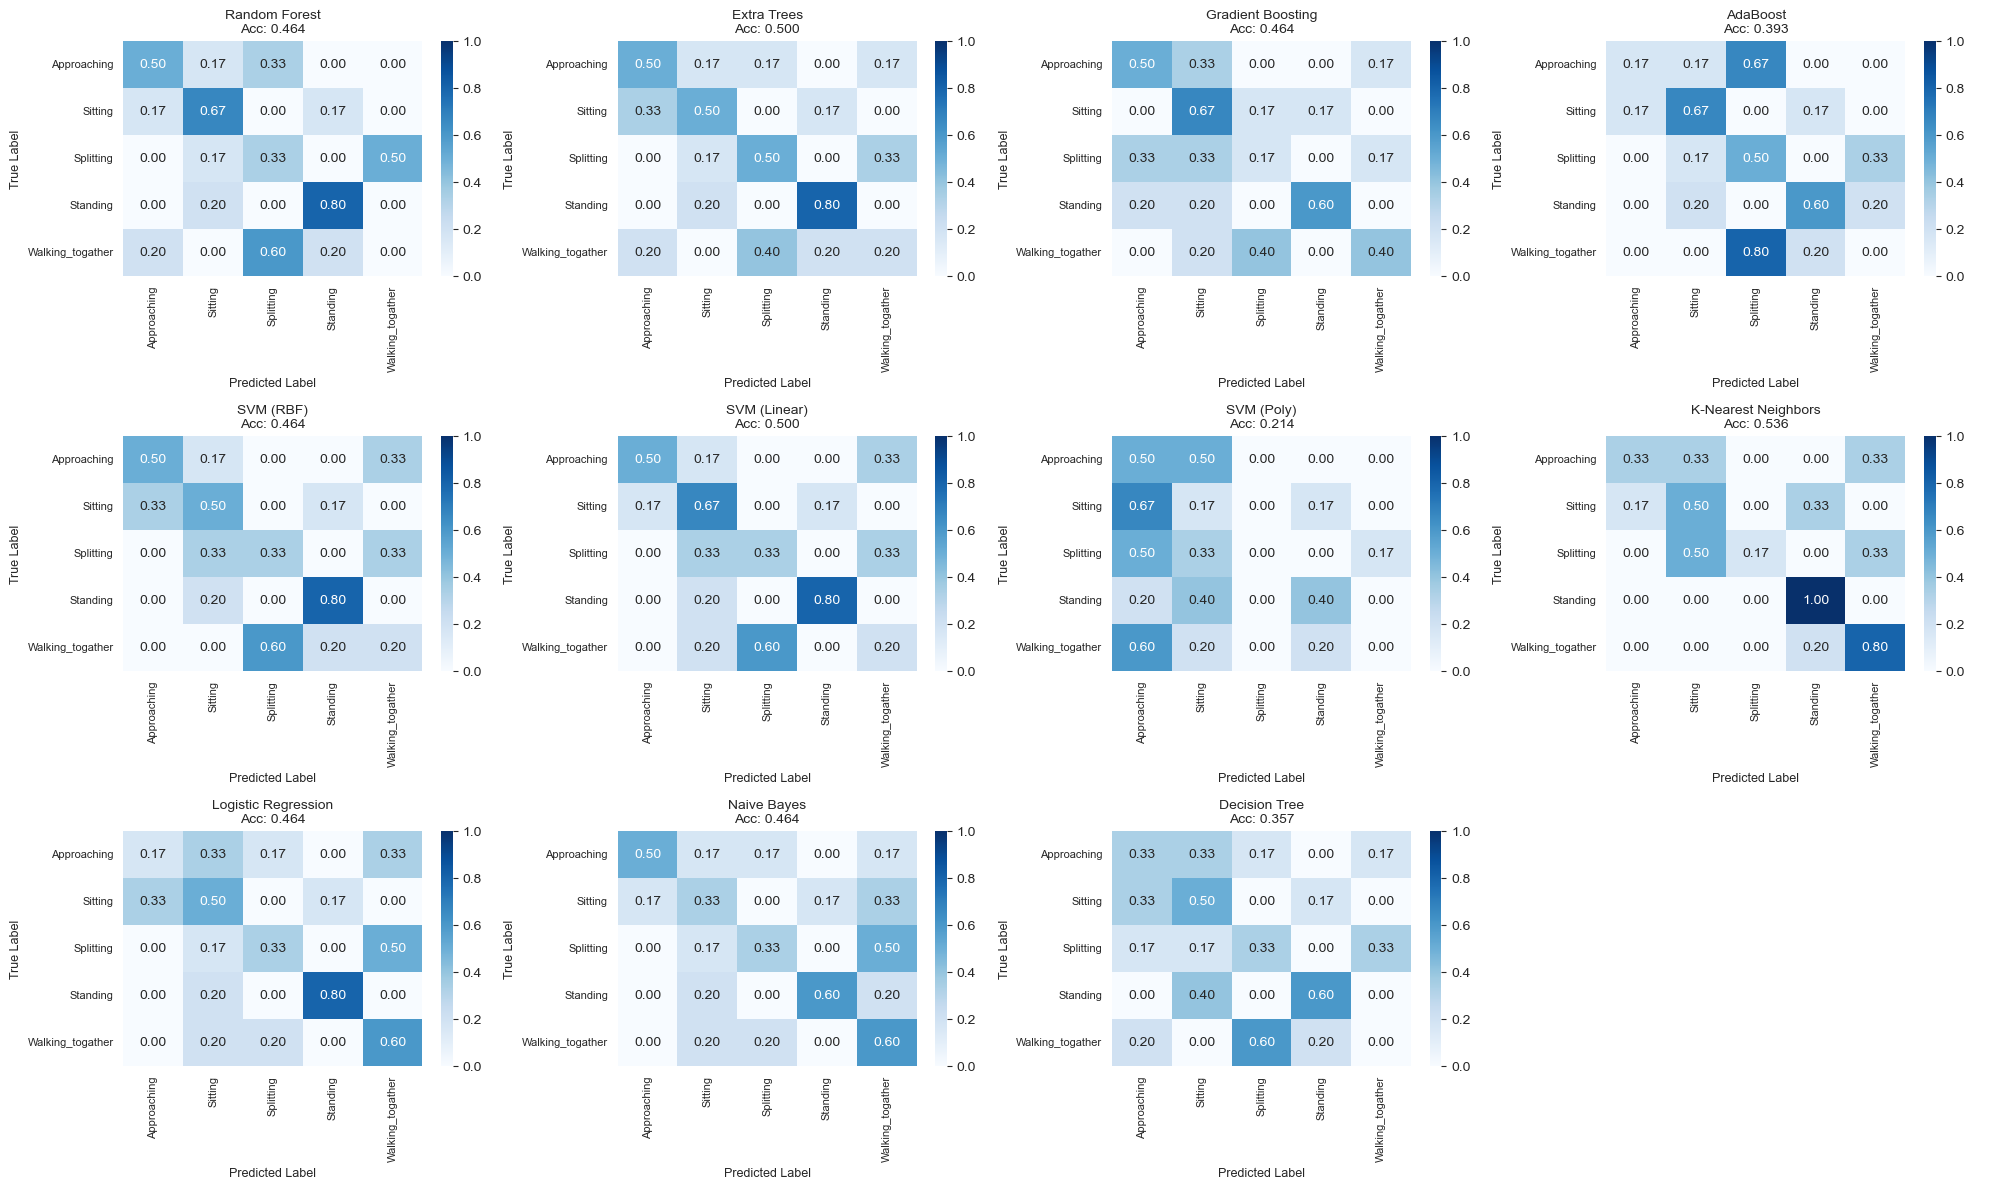

In [25]:
print("\n" + "="*60)
print("STEP 5: VISUALIZING RESULTS")
print("="*60)

print("\nGenerating confusion matrices...")

class_names = label_encoder.classes_
n_models = len(results)

# Arrange in grid (max 4 columns)
n_cols = min(4, n_models)
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))

# Flatten axes array for easier indexing
if n_models == 1:
    axes = [axes]
else:
    axes = axes.flatten() if n_rows > 1 else axes

for idx, (name, result) in enumerate(results.items()):
    cm = confusion_matrix(y_encoded, result['y_pred'])

    # Normalize confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Plot
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
               xticklabels=class_names, yticklabels=class_names,
               ax=axes[idx], cbar=True, vmin=0, vmax=1)
    axes[idx].set_title(f'{name}\nAcc: {result["accuracy"]:.3f}', fontsize=10)
    axes[idx].set_ylabel('True Label', fontsize=9)
    axes[idx].set_xlabel('Predicted Label', fontsize=9)
    axes[idx].tick_params(labelsize=8)

# Hide unused subplots
for idx in range(n_models, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(f"{config.RESULTS_DIR}/confusion_matrices.png", dpi=300, bbox_inches='tight')
print(f"✓ Confusion matrices saved to {config.RESULTS_DIR}/confusion_matrices.png")
plt.show()

## Cell 13: Plot Performance Comparison

Generating performance comparison plot...
✓ Performance comparison saved to results/performance_comparison.png


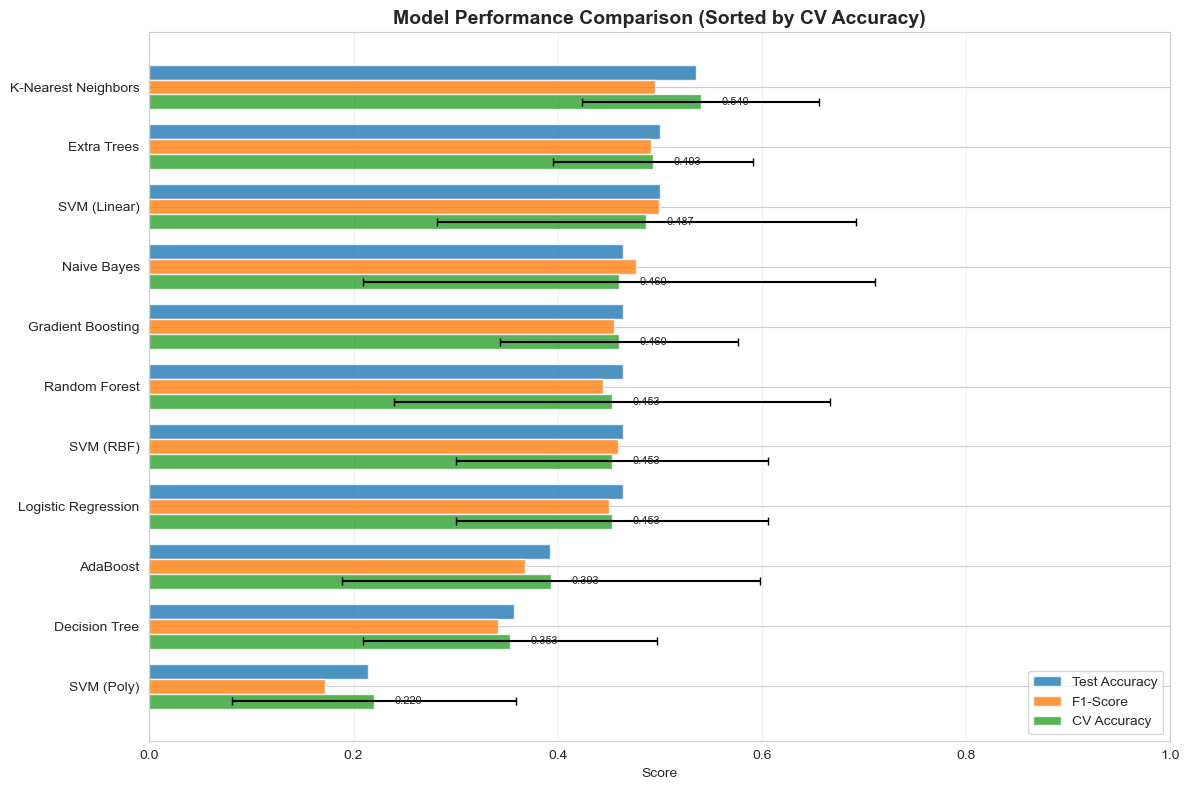

In [26]:
print("Generating performance comparison plot...")

# Prepare data and sort by accuracy
model_data = []
for name in results.keys():
    model_data.append({
        'name': name,
        'accuracy': results[name]['accuracy'],
        'f1_score': results[name]['f1_score'],
        'cv_mean': results[name]['cv_scores'].mean(),
        'cv_std': results[name]['cv_scores'].std()
    })

# Sort by CV accuracy (most reliable metric)
model_data.sort(key=lambda x: x['cv_mean'], reverse=True)

model_names = [m['name'] for m in model_data]
accuracies = [m['accuracy'] for m in model_data]
f1_scores = [m['f1_score'] for m in model_data]
cv_means = [m['cv_mean'] for m in model_data]
cv_stds = [m['cv_std'] for m in model_data]

# Create horizontal bar chart
fig, ax = plt.subplots(figsize=(12, max(8, len(model_names) * 0.6)))

y_pos = np.arange(len(model_names))
height = 0.25

# Plot horizontal bars
ax.barh(y_pos - height, accuracies, height, label='Test Accuracy', alpha=0.8)
ax.barh(y_pos, f1_scores, height, label='F1-Score', alpha=0.8)
ax.barh(y_pos + height, cv_means, height, label='CV Accuracy', alpha=0.8,
       xerr=cv_stds, capsize=3)

ax.set_yticks(y_pos)
ax.set_yticklabels(model_names)
ax.invert_yaxis()  # Best models at top
ax.set_xlabel('Score')
ax.set_title('Model Performance Comparison (Sorted by CV Accuracy)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, (acc, f1, cv) in enumerate(zip(accuracies, f1_scores, cv_means)):
    ax.text(cv + 0.02, i + height, f'{cv:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f"{config.RESULTS_DIR}/performance_comparison.png", dpi=300, bbox_inches='tight')
print(f"✓ Performance comparison saved to {config.RESULTS_DIR}/performance_comparison.png")
plt.show()

## Cell 14: Summary Results Table

In [27]:
# Create comprehensive results summary
print("\n" + "="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)

summary_data = []
for name, result in results.items():
    summary_data.append({
        'Model': name,
        'Accuracy': result['accuracy'],
        'F1-Score': result['f1_score'],
        'CV Mean': result['cv_scores'].mean(),
        'CV Std': result['cv_scores'].std()
    })

summary_df = pd.DataFrame(summary_data).sort_values('CV Mean', ascending=False)
print("\n" + summary_df.to_string(index=False))

# Save to CSV
summary_df.to_csv(f"{config.RESULTS_DIR}/model_comparison.csv", index=False)
print(f"\n✓ Summary saved to {config.RESULTS_DIR}/model_comparison.csv")


MODEL PERFORMANCE SUMMARY

              Model  Accuracy  F1-Score  CV Mean   CV Std
K-Nearest Neighbors  0.535714  0.495552 0.540000 0.116237
        Extra Trees  0.500000  0.490981 0.493333 0.097525
       SVM (Linear)  0.500000  0.499351 0.486667 0.205047
        Naive Bayes  0.464286  0.476190 0.460000 0.250688
  Gradient Boosting  0.464286  0.455556 0.460000 0.116237
      Random Forest  0.464286  0.444555 0.453333 0.213542
          SVM (RBF)  0.464286  0.459291 0.453333 0.152898
Logistic Regression  0.464286  0.450445 0.453333 0.152898
           AdaBoost  0.392857  0.368213 0.393333 0.204831
      Decision Tree  0.357143  0.341837 0.353333 0.143914
         SVM (Poly)  0.214286  0.172222 0.220000 0.139204

✓ Summary saved to results/model_comparison.csv


## Cell 15: Save All Results and Models

In [28]:
print("\n" + "="*60)
print("SAVING RESULTS AND MODELS")
print("="*60)

print("\nSaving detailed per-class results...")

# Detailed per-class results
for name, result in results.items():
    report_df = pd.DataFrame(result['report']).transpose()
    csv_path = f"{config.RESULTS_DIR}/{name.replace(' ', '_').lower()}_report.csv"
    report_df.to_csv(csv_path)
    print(f"  Saved: {csv_path}")

# Save metadata
metadata = {
    'total_samples': len(X_selected),
    'n_features_original': len(extractor.feature_names),
    'n_features_selected': config.N_TOP_FEATURES,
    'n_folds': config.N_FOLDS,
    'behaviors': config.BEHAVIORS,
    'classes': list(label_encoder.classes_)
}

with open(f"{config.RESULTS_DIR}/metadata.txt", 'w') as f:
    for key, value in metadata.items():
        f.write(f"{key}: {value}\n")

print(f"  Saved: {config.RESULTS_DIR}/metadata.txt")

# Save preprocessing objects
print("\nSaving preprocessing objects...")
joblib.dump(scaler, f"{config.MODELS_DIR}/scaler.pkl")
joblib.dump(label_encoder, f"{config.MODELS_DIR}/label_encoder.pkl")
joblib.dump(feature_selector, f"{config.MODELS_DIR}/feature_selector.pkl")
joblib.dump(extractor, f"{config.MODELS_DIR}/feature_extractor.pkl")

print(f"  Scaler saved")
print(f"  Label encoder saved")
print(f"  Feature selector saved")
print(f"  Feature extractor saved")

print(f"\n" + "="*60)
print("✓ PIPELINE COMPLETE!")
print("="*60)
print(f"\nResults saved to: {config.RESULTS_DIR}/")
print(f"Models saved to: {config.MODELS_DIR}/")
print(f"\nKey files:")
print(f"  - model_comparison.csv")
print(f"  - feature_importance.csv")
print(f"  - confusion_matrices.png")
print(f"  - performance_comparison.png")


SAVING RESULTS AND MODELS

Saving detailed per-class results...
  Saved: results/random_forest_report.csv
  Saved: results/extra_trees_report.csv
  Saved: results/gradient_boosting_report.csv
  Saved: results/adaboost_report.csv
  Saved: results/svm_(rbf)_report.csv
  Saved: results/svm_(linear)_report.csv
  Saved: results/svm_(poly)_report.csv
  Saved: results/k-nearest_neighbors_report.csv
  Saved: results/logistic_regression_report.csv
  Saved: results/naive_bayes_report.csv
  Saved: results/decision_tree_report.csv
  Saved: results/metadata.txt

Saving preprocessing objects...
  Scaler saved
  Label encoder saved
  Feature selector saved
  Feature extractor saved

✓ PIPELINE COMPLETE!

Results saved to: results/
Models saved to: models/

Key files:
  - model_comparison.csv
  - feature_importance.csv
  - confusion_matrices.png
  - performance_comparison.png


## Cell 16: Final Summary Statistics

In [29]:
# Final comprehensive statistics
print("\n" + "="*60)
print("FINAL STATISTICS")
print("="*60)

best_model = summary_df.iloc[0]
worst_model = summary_df.iloc[-1]

print(f"\nBest Model: {best_model['Model']}")
print(f"  CV Accuracy: {best_model['CV Mean']:.4f} (+/- {best_model['CV Std']:.4f})")
print(f"  Test Accuracy: {best_model['Accuracy']:.4f}")
print(f"  F1-Score: {best_model['F1-Score']:.4f}")

print(f"\nWorst Model: {worst_model['Model']}")
print(f"  CV Accuracy: {worst_model['CV Mean']:.4f} (+/- {worst_model['CV Std']:.4f})")
print(f"  Test Accuracy: {worst_model['Accuracy']:.4f}")
print(f"  F1-Score: {worst_model['F1-Score']:.4f}")

avg_cv_accuracy = summary_df['CV Mean'].mean()
print(f"\nAverage CV Accuracy (all models): {avg_cv_accuracy:.4f}")

print(f"\nDataset Statistics:")
print(f"  Total Samples: {len(X_selected)}")
print(f"  Total Features (original): {X.shape[1]}")
print(f"  Total Features (selected): {X_selected.shape[1]}")
print(f"  Reduction: {(1 - X_selected.shape[1]/X.shape[1])*100:.1f}%")

print(f"\nClass Distribution:")
for i, class_name in enumerate(label_encoder.classes_):
    count = (y_encoded == i).sum()
    pct = (count / len(y_encoded)) * 100
    print(f"  {class_name}: {count} ({pct:.1f}%)")


FINAL STATISTICS

Best Model: K-Nearest Neighbors
  CV Accuracy: 0.5400 (+/- 0.1162)
  Test Accuracy: 0.5357
  F1-Score: 0.4956

Worst Model: SVM (Poly)
  CV Accuracy: 0.2200 (+/- 0.1392)
  Test Accuracy: 0.2143
  F1-Score: 0.1722

Average CV Accuracy (all models): 0.4333

Dataset Statistics:
  Total Samples: 28
  Total Features (original): 50
  Total Features (selected): 50
  Reduction: 0.0%

Class Distribution:
  Approaching: 6 (21.4%)
  Sitting: 6 (21.4%)
  Splitting: 6 (21.4%)
  Standing: 5 (17.9%)
  Walking_togather: 5 (17.9%)
